In [261]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio.Data import CodonTable
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from statsmodels.stats.multitest import multipletests
from sklearn.mixture import GaussianMixture
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

def read_gene_expression(file_path):
    df = pd.read_csv(file_path, sep='\t')
    return df

def read_somatic_mutations(file_path):
    df = pd.read_csv(file_path, sep='\t')
    return df

def read_patient_metadata(file_path):
    df = pd.read_csv(file_path, sep='\t')
    return df


def handle_missing_data(df: pd.DataFrame,
                        subset_cols: list = None,
                        method: str = "drop") -> pd.DataFrame:

    if method == "drop":
        if subset_cols:
            return df.dropna(subset=subset_cols)
        return df.dropna()
    elif method == "fill":
        numeric = df.select_dtypes(include=[np.number]).columns
        df[numeric] = df[numeric].fillna(df[numeric].mean())
        return df
    else:
        raise ValueError("method must be 'drop' or 'fill'")

def kaplan_meier_survival(df: pd.DataFrame,
                          time_col: str = 'DSS.time',
                          event_col: str = 'DSS') -> KaplanMeierFitter:

    km_df = df[[time_col, event_col]].copy()
    km_df[time_col] = pd.to_numeric(km_df[time_col], errors='coerce')
    km_df[event_col] = pd.to_numeric(km_df[event_col], errors='coerce')
    km_df = handle_missing_data(km_df, subset_cols=[time_col, event_col], method="drop")
    if km_df.empty:
        raise ValueError("No data left for KM after cleaning")
    kmf = KaplanMeierFitter()
    kmf.fit(durations=km_df[time_col], event_observed=km_df[event_col])
    kmf.plot_survival_function()
    return kmf

def cox_proportional_hazards(df: pd.DataFrame,
                             time_col: str,
                             event_col: str,
                             numeric_covs: list,
                             categorical_covs: list) -> CoxPHFitter:

    cph_df = df[[time_col, event_col] + numeric_covs + categorical_covs].copy()
    cph_df[time_col] = pd.to_numeric(cph_df[time_col], errors='coerce')
    cph_df[event_col] = pd.to_numeric(cph_df[event_col], errors='coerce')
    cph_df = handle_missing_data(cph_df, subset_cols=[time_col, event_col] + numeric_covs, method="drop")
    if cph_df.empty:
        raise ValueError("No data left for CoxPH after cleaning")
    cph_df = pd.get_dummies(cph_df, columns=categorical_covs, drop_first=True)
    cph = CoxPHFitter()
    cph.fit(cph_df, duration_col=time_col, event_col=event_col)
    return cph

def add_mutation_status_column(df: pd.DataFrame,
                               gene_col: str = 'Hugo_Symbol',
                               mutation_gene: str = 'TP53') -> pd.DataFrame:

    df = df.copy()
    df['mutation_status'] = np.where(df[gene_col] == mutation_gene,
                                     'mutant',
                                     'wildtype')
    return df


def compute_tmb(somatic_mut: pd.DataFrame) -> pd.Series:
    tmb = somatic_mut['patient_id'].value_counts()
    tmb.name = 'TMB'
    return tmb

Log10 split: 2.858
Exact split: 721 mutations


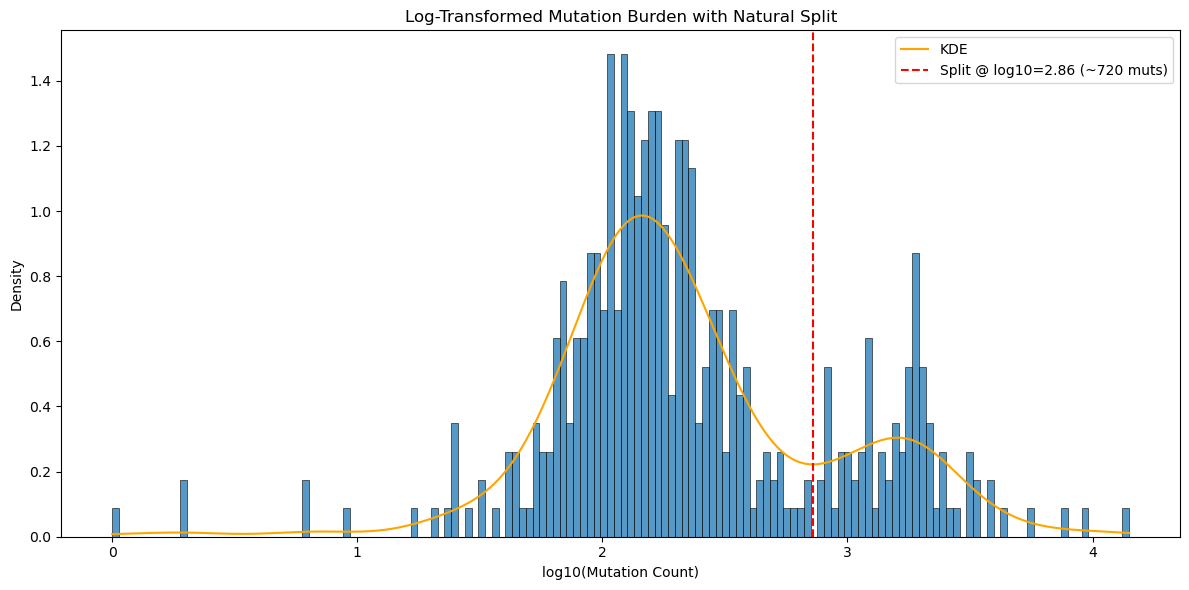

In [158]:
somatic_mut = read_somatic_mutations("/Users/shuhaoxu/Desktop/BNFO285/Groupproject/Project2/TCGA.STAD.mutations.txt")
mutation_counts = somatic_mut['patient_id'].value_counts().sort_index()
counts_array = mutation_counts[mutation_counts > 0].values.astype(float)
log_counts = np.log10(counts_array)

kde = gaussian_kde(log_counts)
x_vals = np.linspace(log_counts.min(), log_counts.max(), 1000)
kde_vals = kde(x_vals)
mask = (x_vals > 1.5) & (x_vals < 3.5)
x_zoom = x_vals[mask]
kde_zoom = kde_vals[mask]

# Find trough (local minimum)
troughs, _ = find_peaks(-kde_zoom)
if len(troughs) > 0:
    log_split = x_zoom[troughs[0]]
    exact_split = 10**log_split
    print(f"Log10 split: {log_split:.3f}")
    print(f"Exact split: {exact_split:.0f} mutations")
else:
    log_split = None
    print("No trough found.")

# Plot
plt.figure(figsize=(12, 6))
sns.histplot(log_counts, bins=150, kde=False, stat="density")
plt.plot(x_vals, kde_vals, color='orange', label='KDE')

# Plot vertical line for the split
if log_split:
    plt.axvline(log_split, color='red', linestyle='--', label=f"Split @ log10={log_split:.2f} (~{int(exact_split)} muts)")

plt.xlabel("log10(Mutation Count)")
plt.ylabel("Density")
plt.title("Log-Transformed Mutation Burden with Natural Split")
plt.legend()
plt.tight_layout()
plt.show()

In [159]:
# Get histogram bin edges from the KDE-aligned plot
hist_bins = np.histogram_bin_edges(log_counts, bins=50)

# Convert log bins to linear mutation counts
linear_bins = 10 ** hist_bins

# Find the largest bin edge that is still less than the exact split
bin_aligned_split = linear_bins[linear_bins < exact_split].max()

print(f"Adjusted split (previous bin edge): {bin_aligned_split:.0f} mutations")

Adjusted split (previous bin edge): 663 mutations


In [162]:
threshold = bin_aligned_split
mutation_counts = somatic_mut['patient_id'].value_counts().sort_index()
mutation_split_df = mutation_counts.to_frame(name="mutation_count")

# Assign groups
mutation_split_df["mutation_group"] = mutation_split_df["mutation_count"].apply(
    lambda x: "High" if x >= threshold else "Low"
)

# Split into patient ID lists
low_patients = mutation_split_df[mutation_split_df["mutation_group"] == "Low"].index.tolist()
high_patients = mutation_split_df[mutation_split_df["mutation_group"] == "High"].index.tolist()

# Filter original mutation rows
low_mut = somatic_mut[somatic_mut['patient_id'].isin(low_patients)]
high_mut = somatic_mut[somatic_mut['patient_id'].isin(high_patients)]

In [34]:
gene_expr = read_gene_expression("/Users/shuhaoxu/Desktop/BNFO285/Groupproject/Project2/TCGA.STAD.expression.txt")
somatic_mut = read_somatic_mutations("/Users/shuhaoxu/Desktop/BNFO285/Groupproject/Project2/TCGA.STAD.mutations.txt")
patient_meta = read_patient_metadata("/Users/shuhaoxu/Desktop/BNFO285/Groupproject/Project2/TCGA.STAD.metadata.txt")

patient_meta['DSS']      = pd.to_numeric(patient_meta['DSS'], errors='coerce')
patient_meta['DSS.time'] = pd.to_numeric(patient_meta['DSS.time'], errors='coerce')

patient_meta = patient_meta.dropna(subset=['DSS', 'DSS.time'])
patient_meta = patient_meta.dropna(subset=['gender','ajcc_pathologic_tumor_stage','histological_grade'])

mutant_ids = somatic_mut.loc[somatic_mut['Hugo_Symbol']=='TP53','patient_id'].unique()
patient_meta['mutation_status'] = np.where(
    patient_meta['patient_id'].isin(mutant_ids),
    'mutant','wildtype'
)

patient_meta = patient_meta.reset_index(drop=True)

In [93]:
patient_meta.dtypes

patient_id                              object
type                                    object
age_at_initial_pathologic_diagnosis    float64
gender                                  object
race                                    object
ajcc_pathologic_tumor_stage             object
histological_type                       object
histological_grade                      object
tumor_status                            object
vital_status                            object
OS                                     float64
OS.time                                float64
DSS                                    float64
DSS.time                               float64
DFI                                    float64
DFI.time                               float64
PFI                                    float64
PFI.time                               float64
Redaction                              float64
mutation_status                         object
TMB                                      int64
TMB_group    

In [51]:
patient_meta.isnull().sum()

patient_id                               0
type                                     0
age_at_initial_pathologic_diagnosis      3
gender                                   0
race                                     0
ajcc_pathologic_tumor_stage              0
histological_type                        0
histological_grade                       0
tumor_status                            19
vital_status                             0
OS                                       0
OS.time                                  0
DSS                                      0
DSS.time                                 0
DFI                                    147
DFI.time                               147
PFI                                      0
PFI.time                                 0
Redaction                              386
mutation_status                          0
TMB                                      0
TMB_group                                0
logTMB                                   0
TTN_mut    

In [107]:
patient_meta["age_at_initial_pathologic_diagnosis"].fillna(0, inplace = True)
patient_meta["DFI"].fillna(0, inplace = True)
patient_meta["DFI.time"].fillna(0, inplace = True)
patient_meta["race"].fillna("Unknown", inplace = True)

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_26413/2531574896.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  patient_meta["race"].fillna("Unknown", inplace = True)


In [108]:
patient_meta.isnull().sum()

patient_id                               0
type                                     0
age_at_initial_pathologic_diagnosis      0
gender                                   0
race                                     0
ajcc_pathologic_tumor_stage              0
histological_type                        0
histological_grade                       0
tumor_status                            19
vital_status                             0
OS                                       0
OS.time                                  0
DSS                                      0
DSS.time                                 0
DFI                                      0
DFI.time                                 0
PFI                                      0
PFI.time                                 0
Redaction                              386
mutation_status                          0
TMB                                      0
TMB_group                                0
logTMB                                   0
TTN_mut    

Text(0.5, 1.0, 'Survival function')

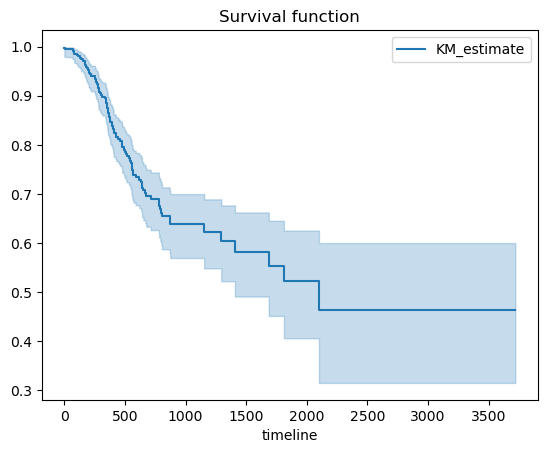

In [67]:
kmf = KaplanMeierFitter()
kmf.fit(durations =  patient_meta['DSS.time'], event_observed = patient_meta['DSS'])
kmf.plot_survival_function()
plt.title('Survival function')

In [70]:
from lifelines.utils import median_survival_times

median_ = kmf.median_survival_time_
median_confidence_interval_ = median_survival_times(kmf.confidence_interval_)
print(median_)
print(median_confidence_interval_)

2100.0
     KM_estimate_lower_0.95  KM_estimate_upper_0.95
0.5                  1407.0                     inf


In [186]:
patient_meta_low = patient_meta[patient_meta.patient_id.isin(low_mut.patient_id)]
patient_meta_high = patient_meta[patient_meta.patient_id.isin(high_mut.patient_id)]

In [222]:
def run_kmf(patient_meta, time, event, feature, feature1, feature2, label):
    plt.figure()
    ax = plt.subplot(111)
    m = (patient_meta[feature] == feature1)
    kmf.fit(durations = patient_meta[m][time], event_observed = patient_meta[m][event], label = feature1)
    kmf.plot_survival_function(ax = ax)
    kmf.fit(durations = patient_meta[~m][time], event_observed = patient_meta[~m][event], label = feature2)
    kmf.plot_survival_function(ax = ax)
    plt.title(f"{label} {event} Survival of different {feature} group")
    plt.xlabel(f"{time} (days)")
    plt.ylabel("Survival Probability")
    plt.show()

# Low mut gender

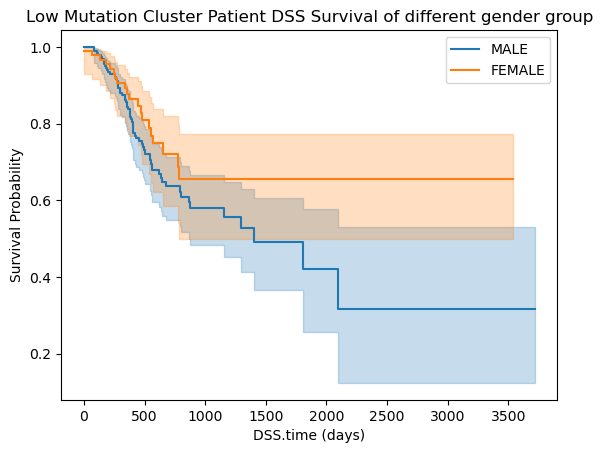

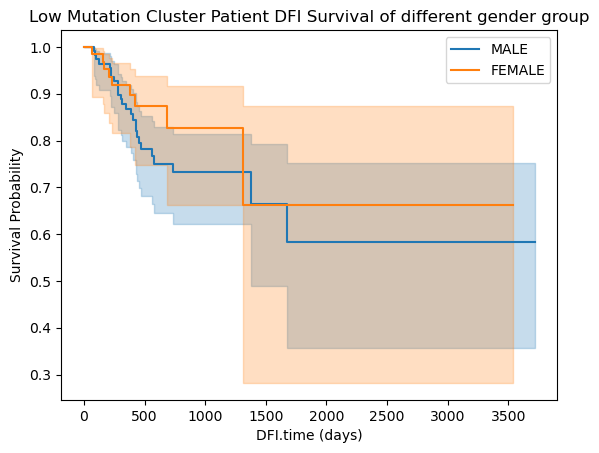

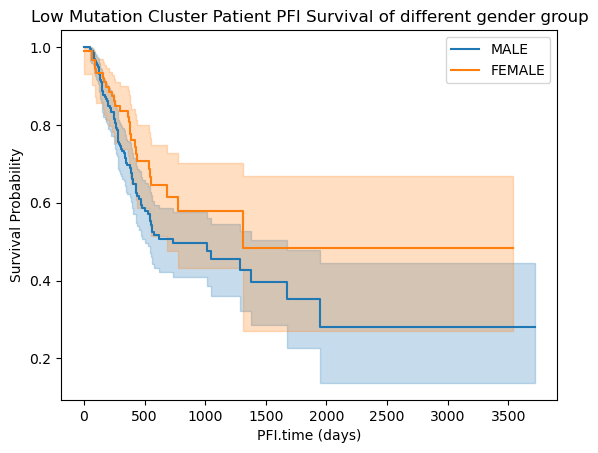

In [223]:
for time,event in [["DSS.time", "DSS"], ["DFI.time", "DFI"], ["PFI.time", "PFI"]]:
    run_kmf(patient_meta_low, time, event, "gender", "MALE", "FEMALE", "Low Mutation Cluster Patient")

# High mut gender

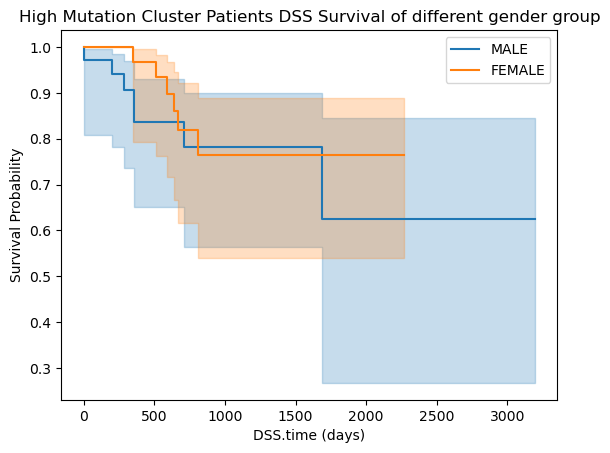

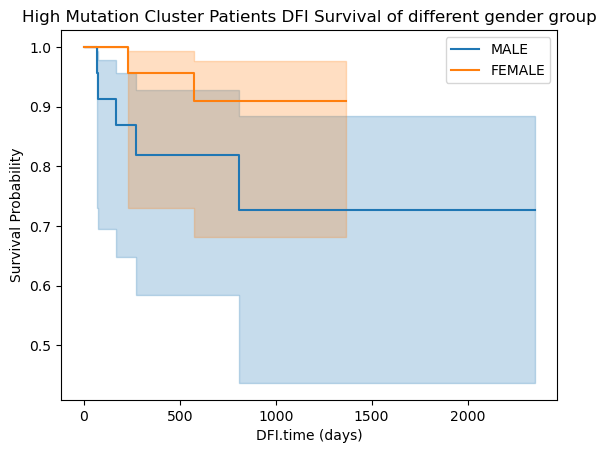

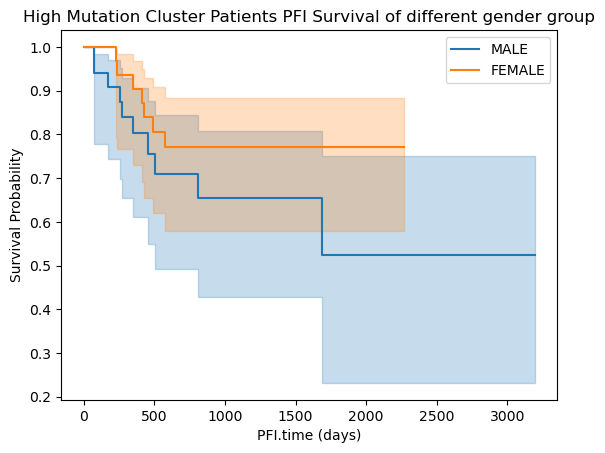

In [224]:
for time,event in [["DSS.time", "DSS"], ["DFI.time", "DFI"], ["PFI.time", "PFI"]]:
    run_kmf(patient_meta_high, time, event, "gender", "MALE", "FEMALE", "High Mutation Cluster Patients")

# low mut Tumor status

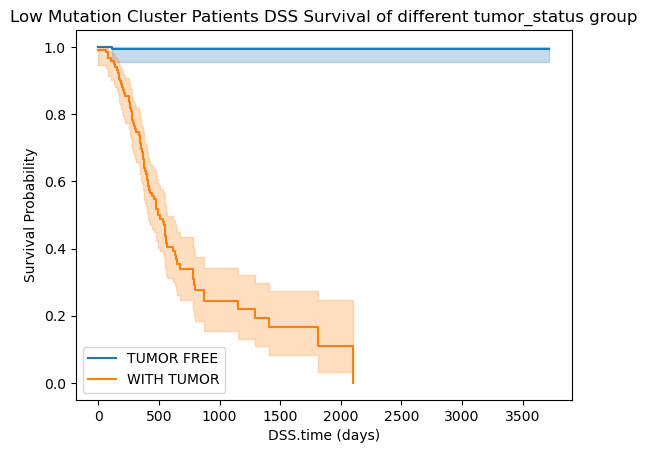

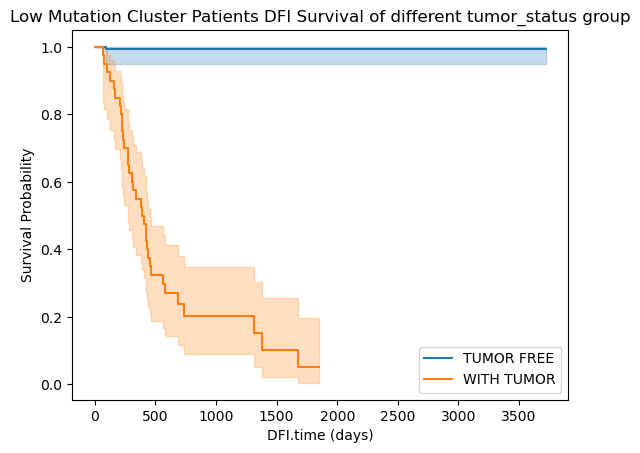

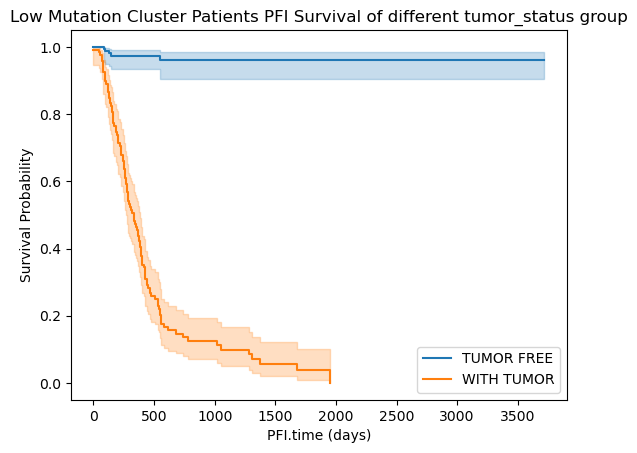

In [225]:
for time,event in [["DSS.time", "DSS"], ["DFI.time", "DFI"], ["PFI.time", "PFI"]]:
    run_kmf(patient_meta_low, time, event, "tumor_status", "TUMOR FREE", "WITH TUMOR", "Low Mutation Cluster Patients")

# High mut tumor status

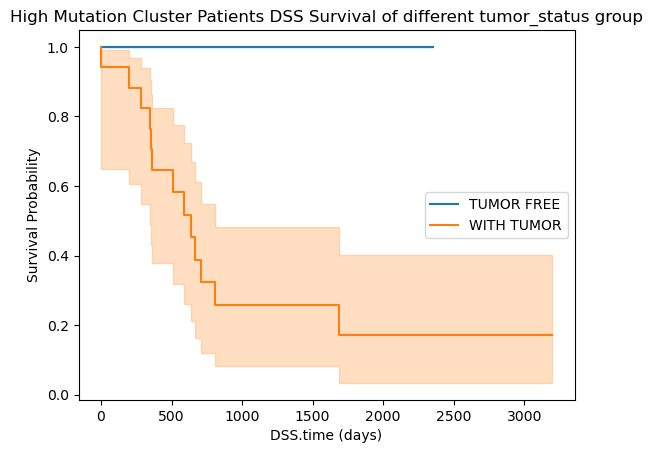

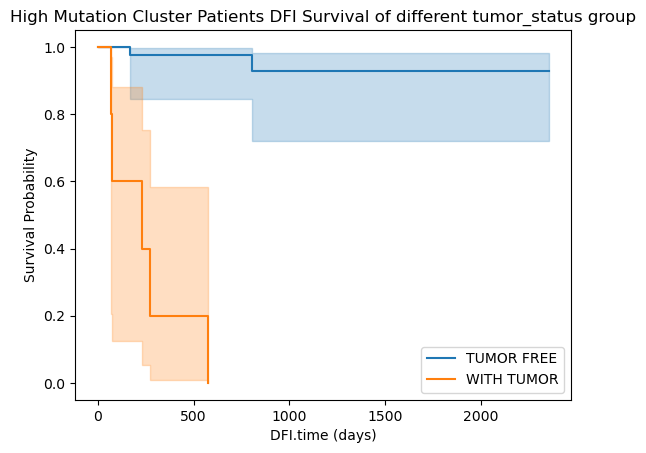

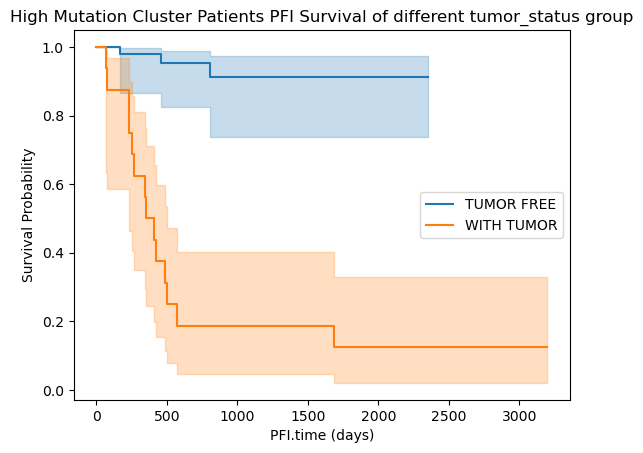

In [227]:
for time,event in [["DSS.time", "DSS"], ["DFI.time", "DFI"], ["PFI.time", "PFI"]]:
    run_kmf(patient_meta_high, time, event, "tumor_status", "TUMOR FREE", "WITH TUMOR", "High Mutation Cluster Patients")

# Separate by race

In [203]:
races = ['ASIAN', 'BLACK OR AFRICAN AMERICAN', 'WHITE']
patient_meta_race = patient_meta[patient_meta.race.isin(races)]

In [230]:
patient_meta_race_low_mut = patient_meta_low[patient_meta_low.race.isin(races)]
patient_meta_race_high_mut = patient_meta_high[patient_meta_high.race.isin(races)]

# Low mut race

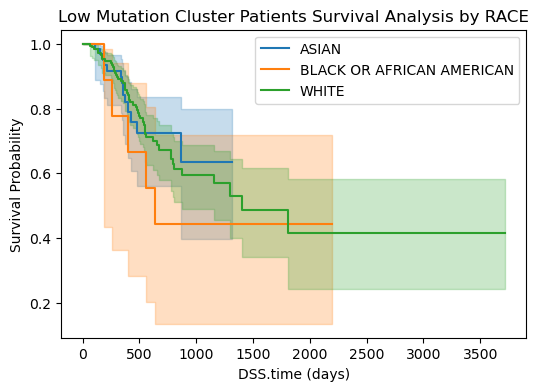

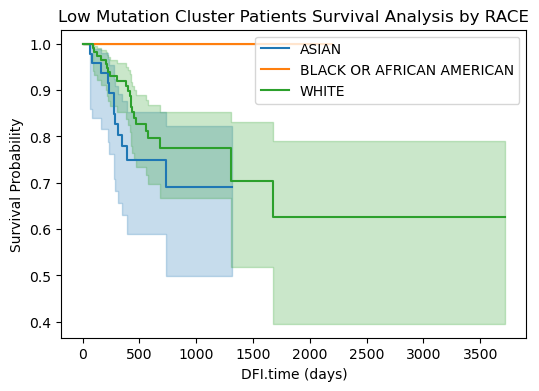

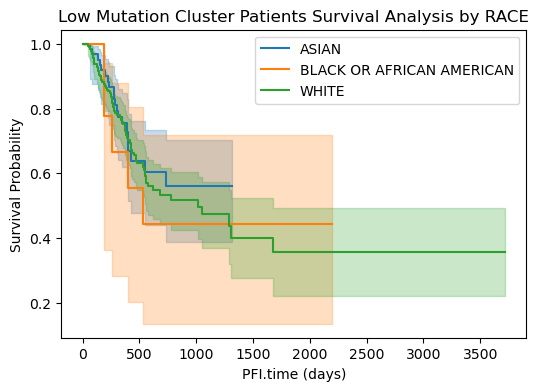

In [232]:
for time,event in [["DSS.time", "DSS"], ["DFI.time", "DFI"], ["PFI.time", "PFI"]]:
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(6,4))
    for grp, sub in patient_meta_race_low_mut.groupby('race'):
        kmf.fit(sub[time], event_observed=sub[event], label=grp)
        kmf.plot_survival_function(ci_show=True)
    plt.title(f"Low Mutation Cluster Patients Survival Analysis by RACE")
    plt.xlabel(f"{time} (days)")
    plt.ylabel("Survival Probability")
    plt.show()

# High mut race

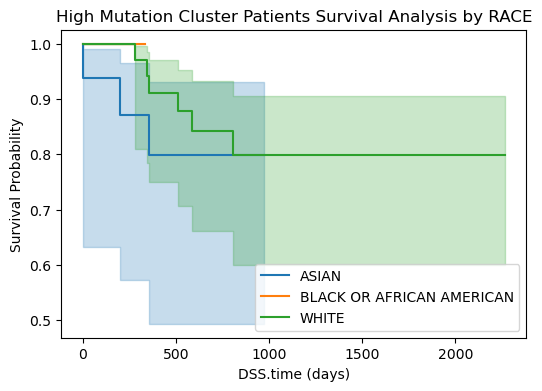

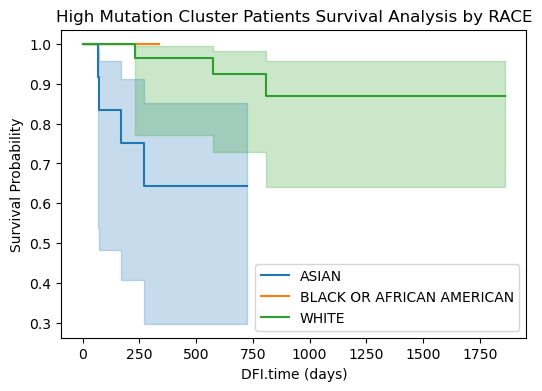

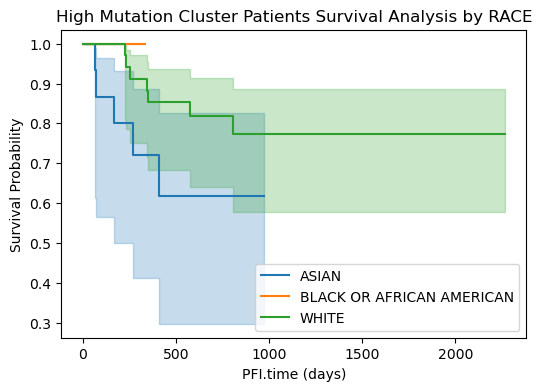

In [233]:
for time,event in [["DSS.time", "DSS"], ["DFI.time", "DFI"], ["PFI.time", "PFI"]]:
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(6,4))
    for grp, sub in patient_meta_race_high_mut.groupby('race'):
        kmf.fit(sub[time], event_observed=sub[event], label=grp)
        kmf.plot_survival_function(ci_show=True)
    plt.title(f"High Mutation Cluster Patients Survival Analysis by RACE")
    plt.xlabel(f"{time} (days)")
    plt.ylabel("Survival Probability")
    plt.show()

# COX proportional

<lifelines.CoxPHFitter: fitted with 337 total observations, 257 right-censored observations>
             duration col = 'DSS.time'
                event col = 'DSS'
      baseline estimation = breslow
   number of observations = 337
number of events observed = 80
   partial log-likelihood = -406.82
         time fit was run = 2025-05-30 07:22:31 UTC

---
                                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                            
age_at_initial_pathologic_diagnosis  0.01      1.01      0.01           -0.01            0.03                0.99                1.03
gender_MALE                          0.44      1.55      0.25           -0.05            0.93                0.95                2.55
race_BLACK OR AFRICAN AMERICAN       0.35      1.42      0.52           -0.67            1.38                0.51                3.98
race_WHITE                          -0.01      0.99      0.28           -0.56            0.53                0.57                1.70

                                     cmp to     z    p  -log2(p)
covariate                                                       
age_at_initial_pathologic_diagnosis    0.00  0.63 0.53      0.92
gender_MALE                            0.00  1.75 0.08      3.64
race_BLACK OR AFRICAN AMERICAN         0.00  0.68 0.50      1.00
race_WHITE                             0.00 -0.05 0.96      0.06
---
Concordance = 0.56
Partial AIC = 821.63
log-likelihood ratio test = 4.55 on 4 df
-log2(p) of ll-ratio test = 1.57

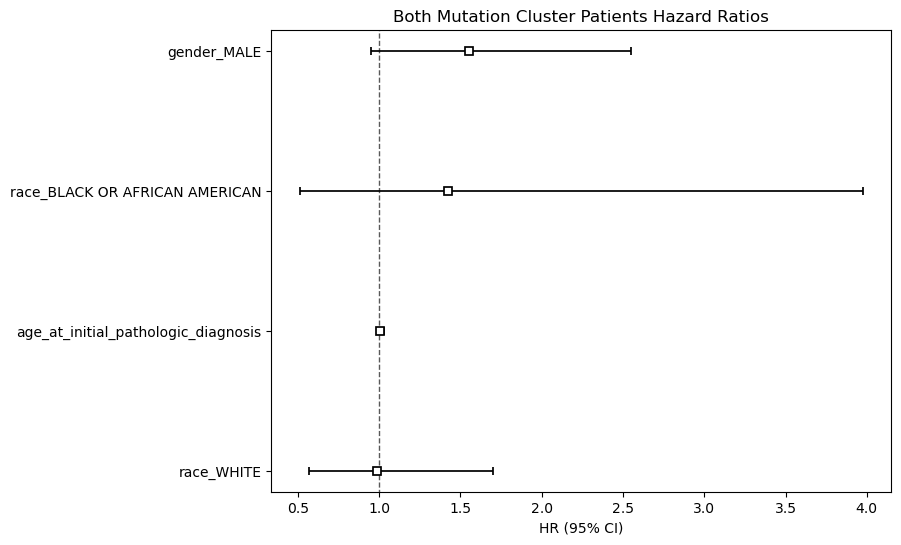

In [262]:
cph = cox_proportional_hazards(
    patient_meta_race,
    time_col   = 'DSS.time',
    event_col  = 'DSS',
    numeric_covs     = ['age_at_initial_pathologic_diagnosis'],
    categorical_covs = ['gender','race']
)

cph.print_summary()

plt.figure(figsize=(8,6))
ax = cph.plot(hazard_ratios=True)
ax.set_title("Both Mutation Cluster Patients Hazard Ratios")
plt.show()

<lifelines.CoxPHFitter: fitted with 275 total observations, 204 right-censored observations>
             duration col = 'DSS.time'
                event col = 'DSS'
      baseline estimation = breslow
   number of observations = 275
number of events observed = 71
   partial log-likelihood = -344.13
         time fit was run = 2025-05-30 07:22:33 UTC

---
                                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                            
age_at_initial_pathologic_diagnosis  0.00      1.00      0.01           -0.02            0.03                0.98                1.03
gender_MALE                          0.27      1.31      0.27           -0.27            0.81                0.77                2.24
race_BLACK OR AFRICAN AMERICAN       0.40      1.50      0.54           -0.65            1.45                0.52                4.28
race_WHITE                           0.06      1.06      0.30           -0.54            0.65                0.58                1.92

                                     cmp to    z    p  -log2(p)
covariate                                                      
age_at_initial_pathologic_diagnosis    0.00 0.37 0.71      0.48
gender_MALE                            0.00 0.99 0.32      1.64
race_BLACK OR AFRICAN AMERICAN         0.00 0.75 0.45      1.14
race_WHITE                             0.00 0.18 0.86      0.23
---
Concordance = 0.54
Partial AIC = 696.26
log-likelihood ratio test = 1.92 on 4 df
-log2(p) of ll-ratio test = 0.41

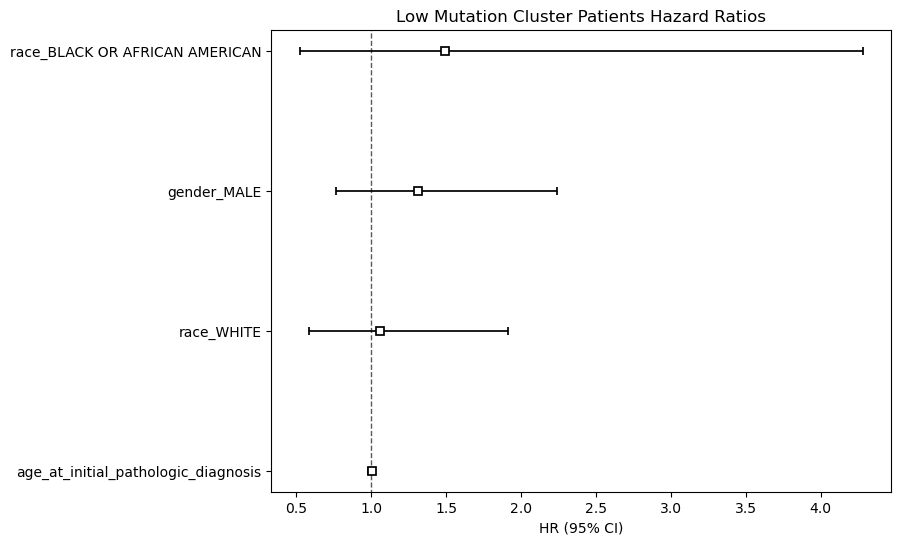

In [263]:
cph = cox_proportional_hazards(
    patient_meta_race_low_mut,
    time_col   = 'DSS.time',
    event_col  = 'DSS',
    numeric_covs     = ['age_at_initial_pathologic_diagnosis'],
    categorical_covs = ['gender','race']
)

cph.print_summary()

plt.figure(figsize=(8,6))
ax = cph.plot(hazard_ratios=True)
ax.set_title("Low Mutation Cluster Patients Hazard Ratios")
plt.show()

/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/lifelines/utils/__init__.py:1120: ConvergenceWarning: Column race_BLACK OR AFRICAN AMERICAN have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['DSS'].astype(bool)
>>> print(df.loc[events, 'race_BLACK OR AFRICAN AMERICAN'].var())
>>> print(df.loc[~events, 'race_BLACK OR AFRICAN AMERICAN'].var())

A very low variance means that the column race_BLACK OR AFRICAN AMERICAN completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but 

<lifelines.CoxPHFitter: fitted with 62 total observations, 53 right-censored observations>
             duration col = 'DSS.time'
                event col = 'DSS'
      baseline estimation = breslow
   number of observations = 62
number of events observed = 9
   partial log-likelihood = -31.40
         time fit was run = 2025-05-30 07:20:20 UTC

---
                                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                             
age_at_initial_pathologic_diagnosis   0.06      1.07      0.04           -0.02            0.15                0.98                1.16
gender_MALE                           0.55      1.74      0.68           -0.78            1.89                0.46                6.61
race_BLACK OR AFRICAN AMERICAN      -15.00      0.00   3047.95        -5988.87         5958.87                0.00                 inf
race_WHITE                           -0.72      0.49      0.76           -2.22            0.78                0.11                2.18

                                     cmp to     z    p  -log2(p)
covariate                                                       
age_at_initial_pathologic_diagnosis    0.00  1.51 0.13      2.94
gender_MALE                            0.00  0.81 0.42      1.26
race_BLACK OR AFRICAN AMERICAN         0.00 -0.00 1.00      0.01
race_WHITE                             0.00 -0.94 0.35      1.52
---
Concordance = 0.74
Partial AIC = 70.80
log-likelihood ratio test = 3.76 on 4 df
-log2(p) of ll-ratio test = 1.19

/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:2636: RuntimeWarning: overflow encountered in exp
  upper_errors = exp_log_hazards * (exp(z * self.standard_errors_[columns].values) - 1)


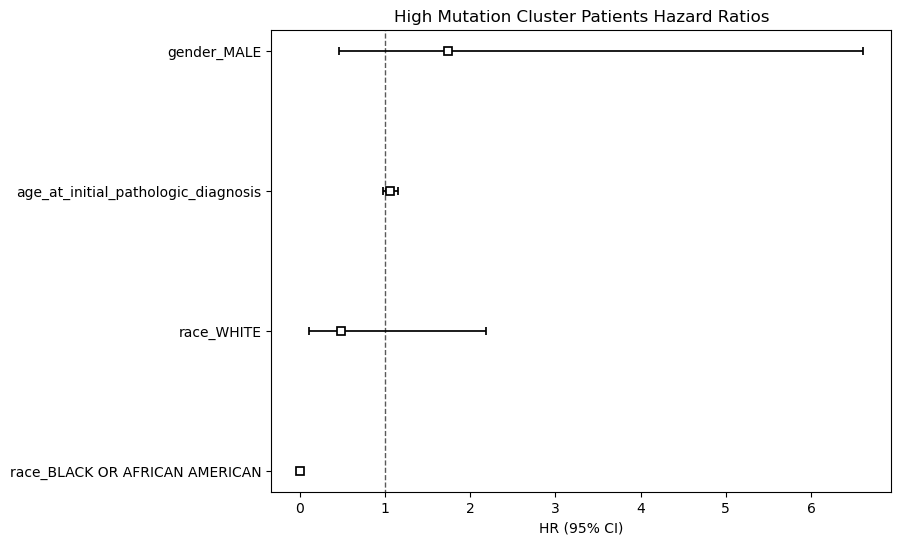

In [255]:
cph = cox_proportional_hazards(
    patient_meta_race_high_mut,
    time_col   = 'DSS.time',
    event_col  = 'DSS',
    numeric_covs     = ['age_at_initial_pathologic_diagnosis'],
    categorical_covs = ['gender','race']
)

cph.print_summary()

plt.figure(figsize=(8,6))
ax = cph.plot(hazard_ratios=True)
ax.set_title("High Mutation Cluster Patients Hazard Ratios")
plt.show()

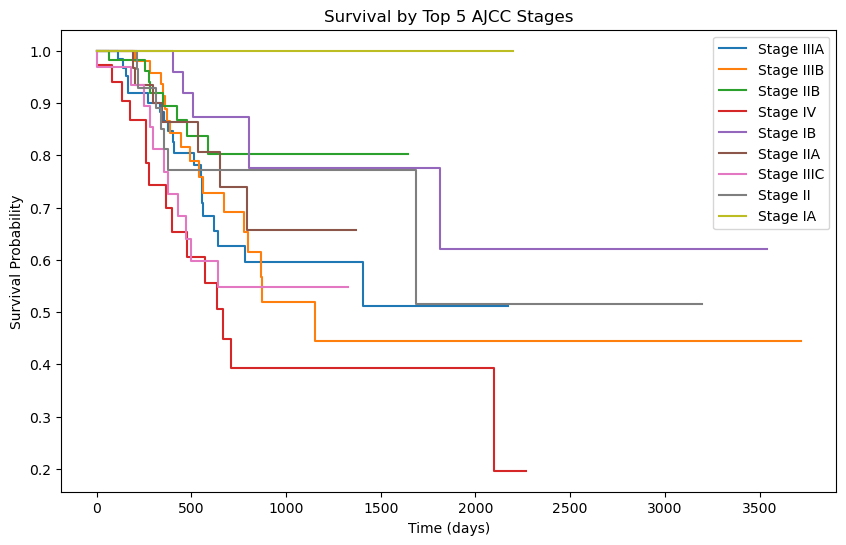

In [150]:
plt.figure(figsize=(10,6))
top_stages = patient_meta['ajcc_pathologic_tumor_stage'].value_counts().index[:9]
for stage in top_stages:
    sub = patient_meta[patient_meta['ajcc_pathologic_tumor_stage']==stage]
    kmf.fit(durations = sub['DSS.time'], event_observed=sub['DSS'], label=stage)
    kmf.plot_survival_function(ci_show=False)
plt.title("Survival by Top 5 AJCC Stages")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.show()

<Axes: >

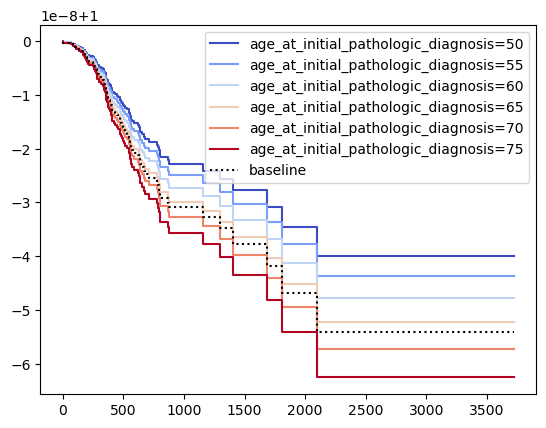

In [192]:
cph.plot_partial_effects_on_outcome(covariates = 'age_at_initial_pathologic_diagnosis', values = [50, 55, 60, 65, 70, 75], cmap = 'coolwarm')

# Top genes but looking at them separated by race

In [243]:
def top_genes_kmf(patient_meta, somatic_mut, top_genes, label, event, time):
    colors = plt.cm.tab10.colors
    kmf = KaplanMeierFitter()
    fig, ax = plt.subplots(figsize=(10, 6))

    for i, gene in enumerate(top_genes):
        # mark mutation status
        patient_meta[f'{gene}_mut'] = np.where(
            patient_meta['patient_id'].isin( 
                somatic_mut[somatic_mut['Hugo_Symbol'] == gene]['patient_id']
            ),
            1, 0
        )

        color = colors[i % len(colors)]
        # plot Wild-Type
        wt = patient_meta[patient_meta[f'{gene}_mut'] == 0]
        kmf.fit(wt[time], event_observed=wt[event], label=f"{gene} WT")
        kmf.plot_survival_function(ax=ax, ci_show=False,
                                   color=color, linestyle='-')
        # plot Mutant
        mut = patient_meta[patient_meta[f'{gene}_mut'] == 1]
        kmf.fit(mut[time], event_observed=mut[event], label=f"{gene} Mut")
        kmf.plot_survival_function(ax=ax, ci_show=False,
                                   color=color, linestyle='--')
    
    plt.title(f"{label} Survival Analysis {event}")
    plt.xlabel(f"{time} (days)")
    plt.ylabel("Survival Probability")
    plt.show()

In [235]:
patient_meta_race.race.value_counts()

race
WHITE                        242
ASIAN                         83
BLACK OR AFRICAN AMERICAN     12
Name: count, dtype: int64

# Low mut top genes

ASIAN


<Figure size 600x400 with 0 Axes>

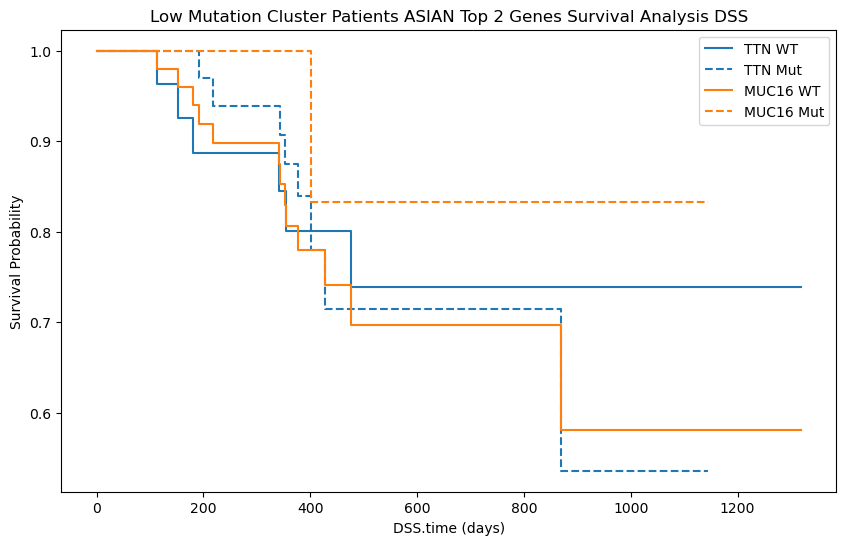

BLACK OR AFRICAN AMERICAN


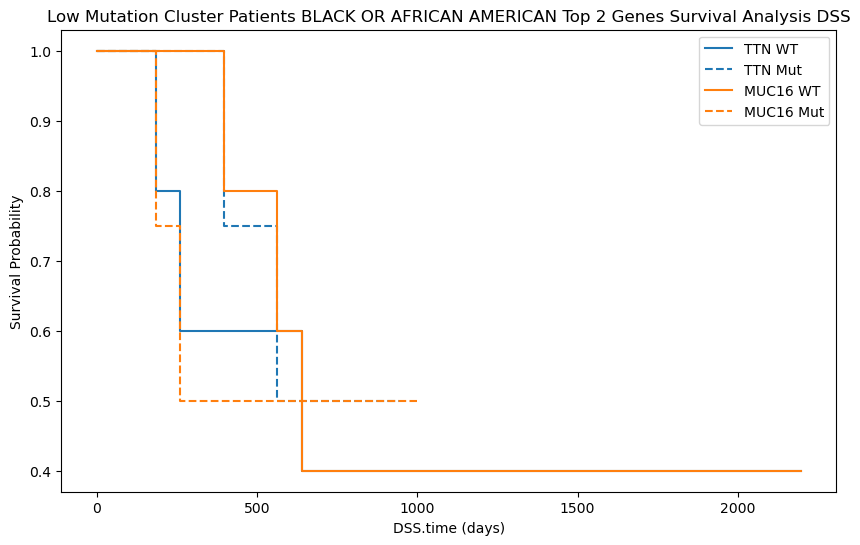

WHITE


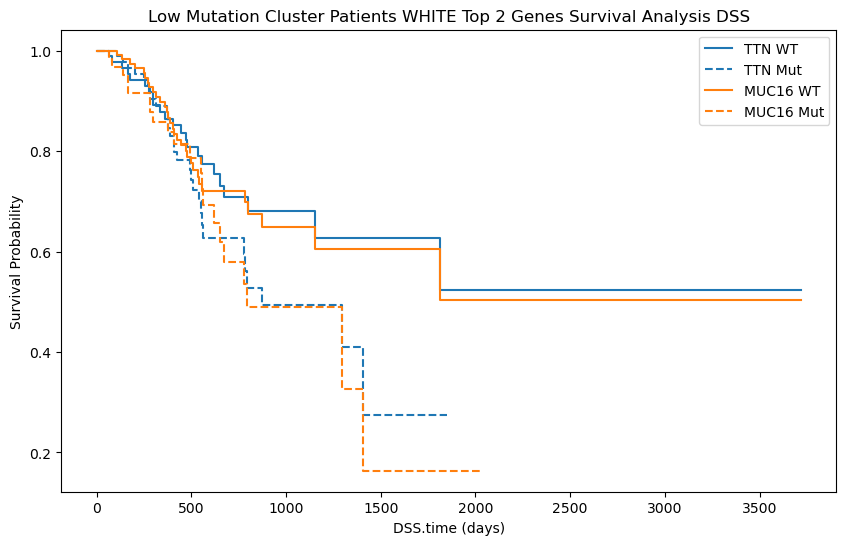

ASIAN


<Figure size 600x400 with 0 Axes>

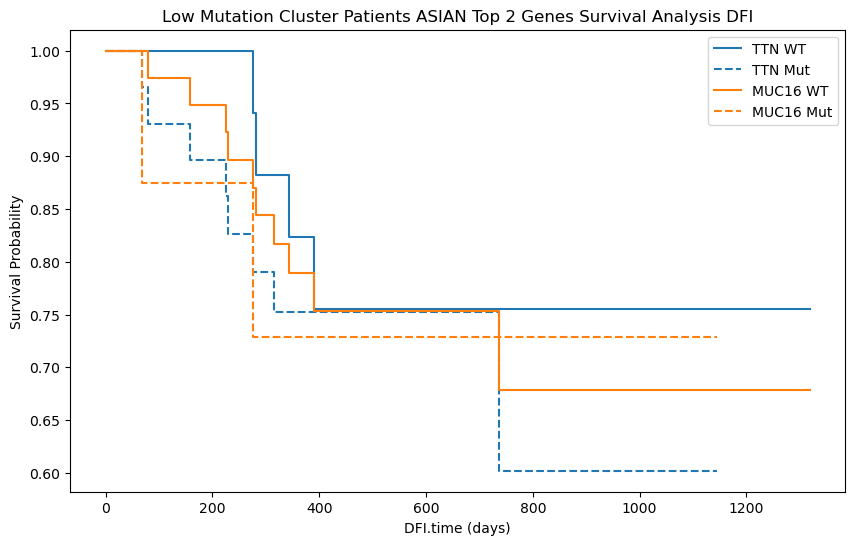

BLACK OR AFRICAN AMERICAN


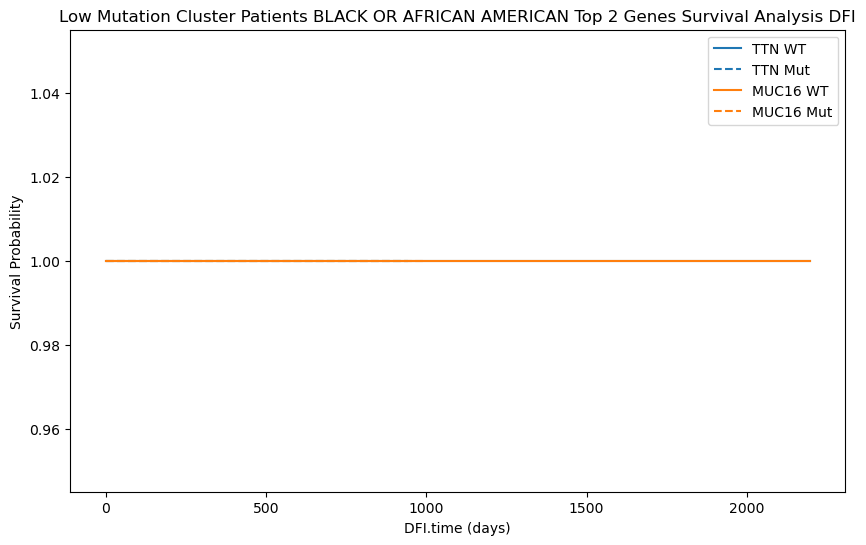

WHITE


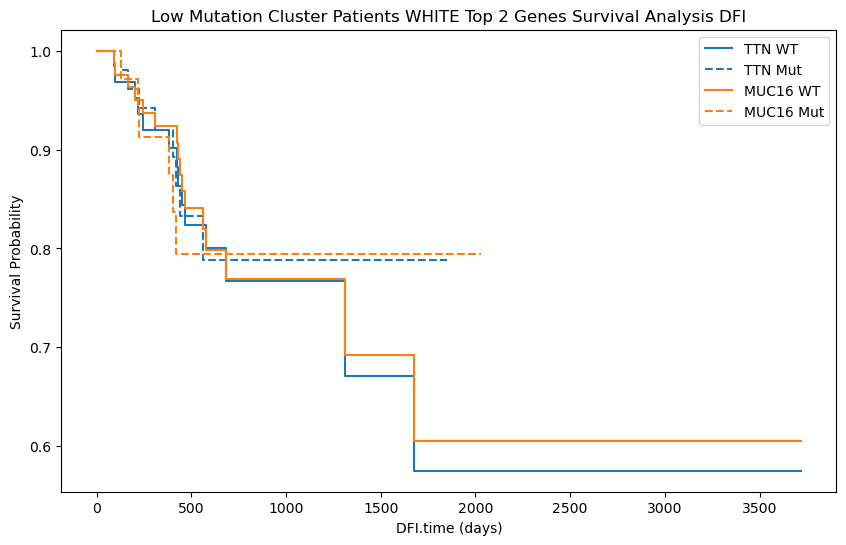

ASIAN


<Figure size 600x400 with 0 Axes>

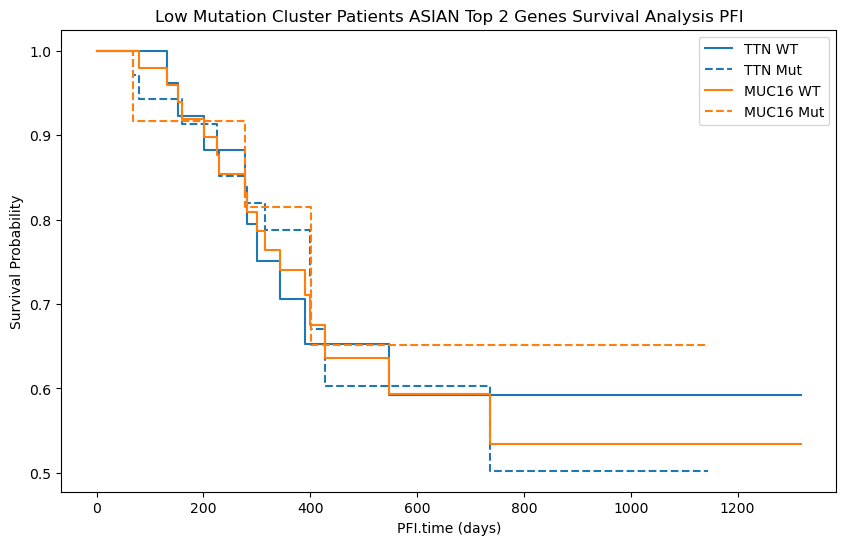

BLACK OR AFRICAN AMERICAN


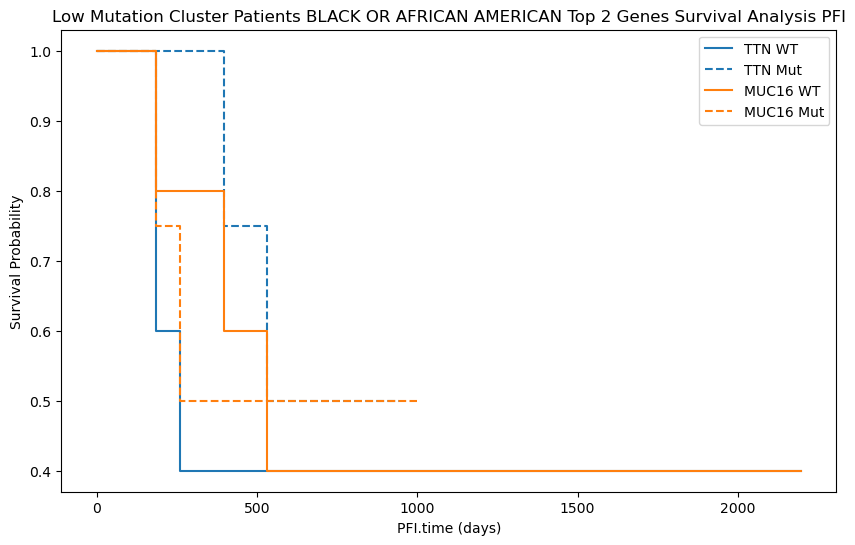

WHITE


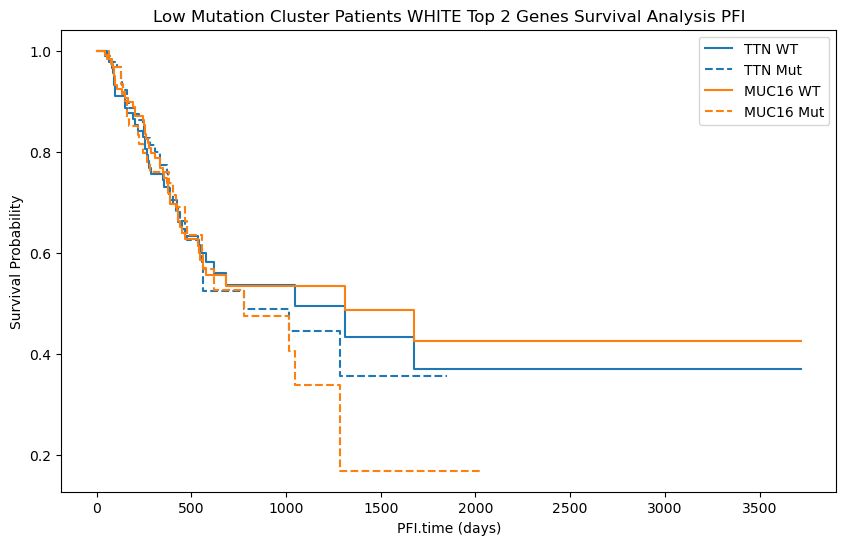

In [244]:
top = 2
top_genes = (
    somatic_mut['Hugo_Symbol']
    .value_counts()
    .nlargest(top)
    .index
    .tolist()
)

for time,event in [["DSS.time", "DSS"], ["DFI.time", "DFI"], ["PFI.time", "PFI"]]:
    plt.figure(figsize=(6,4))
    for grp, sub in patient_meta_race_low_mut.groupby('race'):
        print(grp)
        top_genes_kmf(sub, somatic_mut, top_genes, f"Low Mutation Cluster Patients {grp} Top {top} Genes", event, time)

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_26413/3717744076.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patient_meta_race_low_mut[f'{gene}_mut'] = np.where(
/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_26413/3717744076.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patient_meta_race_low_mut[f'{gene}_mut'] = np.where(


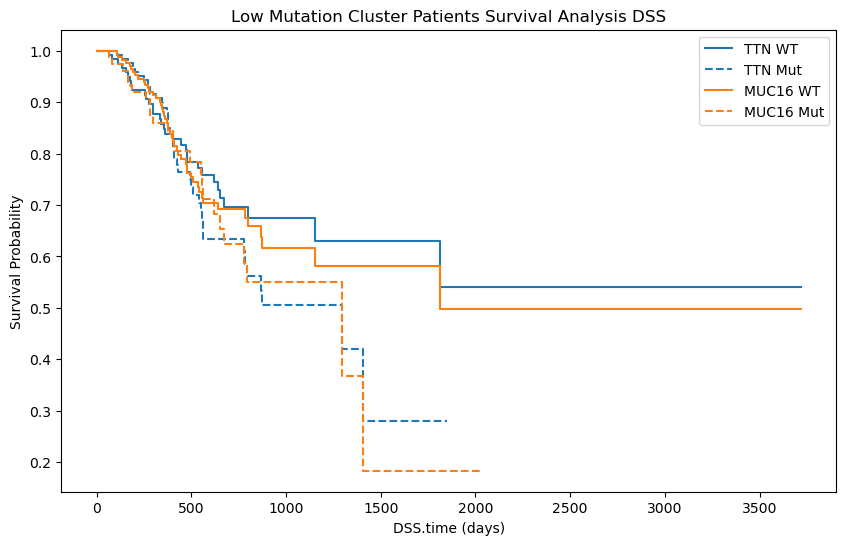

In [248]:
colors = plt.cm.tab10.colors
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(10, 6))

for i, gene in enumerate(top_genes):
    # mark mutation status
    patient_meta_race_low_mut[f'{gene}_mut'] = np.where(
        patient_meta_race_low_mut['patient_id'].isin( 
            somatic_mut[somatic_mut['Hugo_Symbol'] == gene]['patient_id']
        ),
        1, 0
    )

    color = colors[i % len(colors)]
    # plot Wild-Type
    wt = patient_meta_race_low_mut[patient_meta_race_low_mut[f'{gene}_mut'] == 0]
    kmf.fit(wt[time], event_observed=wt[event], label=f"{gene} WT")
    kmf.plot_survival_function(ax=ax, ci_show=False,
                               color=color, linestyle='-')
    # plot Mutant
    mut = patient_meta_race_low_mut[patient_meta_race_low_mut[f'{gene}_mut'] == 1]
    kmf.fit(mut[time], event_observed=mut[event], label=f"{gene} Mut")
    kmf.plot_survival_function(ax=ax, ci_show=False,
                               color=color, linestyle='--')

plt.title(f"Low Mutation Cluster Patients Survival Analysis DSS")
plt.xlabel(f"DSS.time (days)")
plt.ylabel("Survival Probability")
plt.show()

# High mut top genes

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_26413/3163423188.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patient_meta_race_high_mut[f'{gene}_mut'] = np.where(
/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_26413/3163423188.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patient_meta_race_high_mut[f'{gene}_mut'] = np.where(


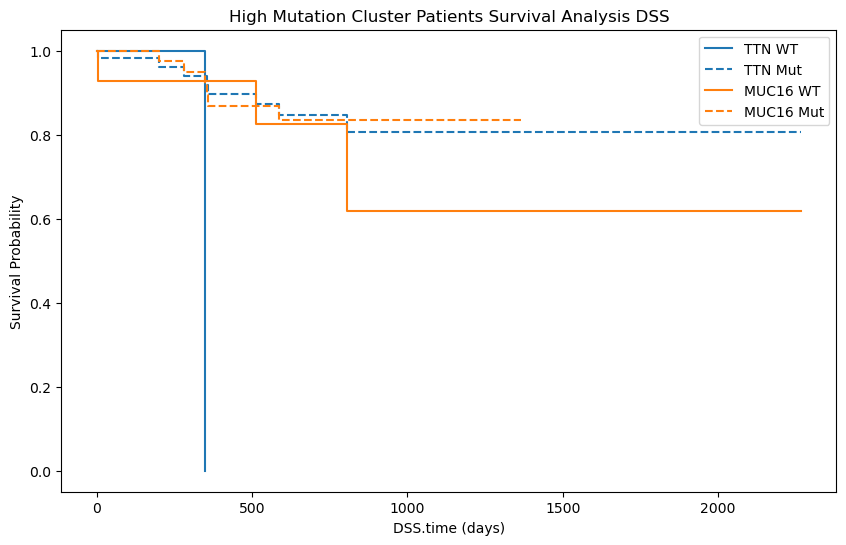

In [247]:
colors = plt.cm.tab10.colors
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(10, 6))

for i, gene in enumerate(top_genes):
    # mark mutation status
    patient_meta_race_high_mut[f'{gene}_mut'] = np.where(
        patient_meta_race_high_mut['patient_id'].isin( 
            somatic_mut[somatic_mut['Hugo_Symbol'] == gene]['patient_id']
        ),
        1, 0
    )

    color = colors[i % len(colors)]
    # plot Wild-Type
    wt = patient_meta_race_high_mut[patient_meta_race_high_mut[f'{gene}_mut'] == 0]
    kmf.fit(wt[time], event_observed=wt[event], label=f"{gene} WT")
    kmf.plot_survival_function(ax=ax, ci_show=False,
                               color=color, linestyle='-')
    # plot Mutant
    mut = patient_meta_race_high_mut[patient_meta_race_high_mut[f'{gene}_mut'] == 1]
    kmf.fit(mut[time], event_observed=mut[event], label=f"{gene} Mut")
    kmf.plot_survival_function(ax=ax, ci_show=False,
                               color=color, linestyle='--')

plt.title(f"High Mutation Cluster Patients Survival Analysis DSS")
plt.xlabel(f"DSS.time (days)")
plt.ylabel("Survival Probability")
plt.show()

# Other

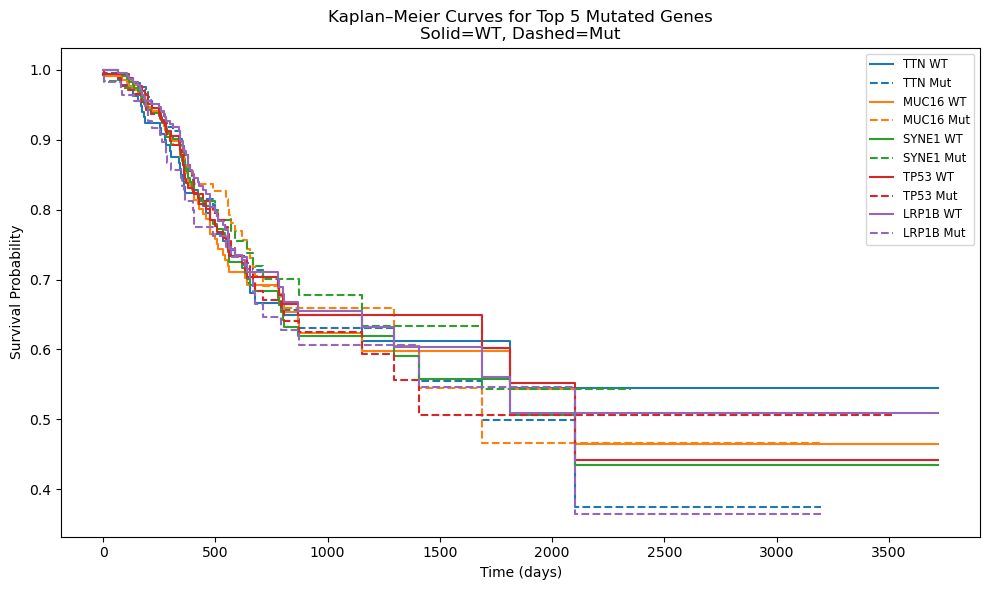

In [43]:
top_genes = (
    somatic_mut['Hugo_Symbol']
    .value_counts()
    .nlargest(5)
    .index
    .tolist()
)

results = []

# Prepare combined KM plot
colors = plt.cm.tab10.colors
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(10, 6))

for i, gene in enumerate(top_genes):
    # mark mutation status
    patient_meta[f'{gene}_mut'] = np.where(
        patient_meta['patient_id'].isin(
            somatic_mut[somatic_mut['Hugo_Symbol'] == gene]['patient_id']
        ),
        1, 0
    )

    color = colors[i % len(colors)]
    # plot Wild-Type
    wt = patient_meta[patient_meta[f'{gene}_mut'] == 0]
    kmf.fit(wt['DSS.time'], event_observed=wt['DSS'], label=f"{gene} WT")
    kmf.plot_survival_function(ax=ax, ci_show=False,
                               color=color, linestyle='-')
    # plot Mutant
    mut = patient_meta[patient_meta[f'{gene}_mut'] == 1]
    kmf.fit(mut['DSS.time'], event_observed=mut['DSS'], label=f"{gene} Mut")
    kmf.plot_survival_function(ax=ax, ci_show=False,
                               color=color, linestyle='--')

    # CoxPH (age + gender)
    cph_df = patient_meta[[
        'DSS.time', 'DSS',
        'age_at_initial_pathologic_diagnosis',
        'gender', f'{gene}_mut'
    ]].copy()
    cph_df = pd.get_dummies(cph_df, columns=['gender'], drop_first=True).dropna()
    cph = CoxPHFitter()
    cph.fit(cph_df, duration_col='DSS.time', event_col='DSS')
    hr = np.exp(cph.params_[f'{gene}_mut'])
    ci_low, ci_up = cph.confidence_intervals_.loc[f'{gene}_mut'].values

    results.append({
        'gene': gene,
        'logrank_p': lr.p_value,
        'coxHR': hr,
        'HR_CI_lower': ci_low,
        'HR_CI_upper': ci_up
    })

# finalize KM plot
ax.set_title("Kaplan–Meier Curves for Top 5 Mutated Genes\nSolid=WT, Dashed=Mut")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Survival Probability")
ax.legend(loc='best', fontsize='small')
plt.tight_layout()
plt.show()

# compile and print results
res_df = pd.DataFrame(results)

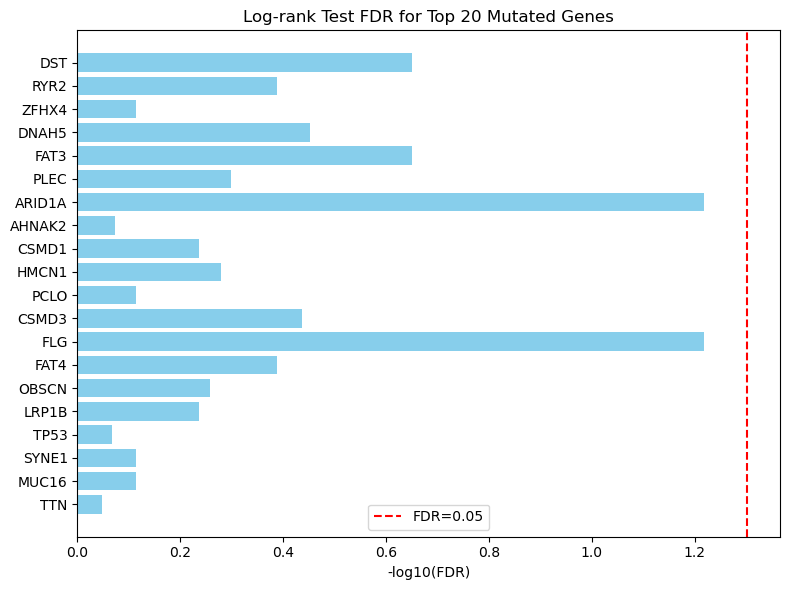

In [19]:
top_genes = somatic_mut['Hugo_Symbol'].value_counts().nlargest(20).index.tolist()
results = []
for gene in top_genes:
    patient_meta[f'{gene}_mut'] = np.where(
        patient_meta['patient_id'].isin(
            somatic_mut[somatic_mut['Hugo_Symbol']==gene]['patient_id']
        ), 1, 0
    )
    if patient_meta[f'{gene}_mut'].nunique() < 2:
        continue
    wt = patient_meta[patient_meta[f'{gene}_mut']==0]
    mut = patient_meta[patient_meta[f'{gene}_mut']==1]
    lr = logrank_test(
        wt['DSS.time'], mut['DSS.time'],
        event_observed_A=wt['DSS'], event_observed_B=mut['DSS']
    )
    results.append({'gene': gene, 'logrank_p': lr.p_value})

res_df = pd.DataFrame(results)
res_df['fdr'] = multipletests(res_df['logrank_p'], method='fdr_bh')[1]
res_df['minus_log10_fdr'] = -np.log10(res_df['fdr'])

plt.figure(figsize=(8,6))
plt.barh(res_df['gene'], res_df['minus_log10_fdr'], color='skyblue')
plt.axvline(-np.log10(0.05), color='red', linestyle='--', label='FDR=0.05')
plt.xlabel('-log10(FDR)')
plt.title('Log-rank Test FDR for Top 20 Mutated Genes')
plt.legend()
plt.tight_layout()
plt.show()

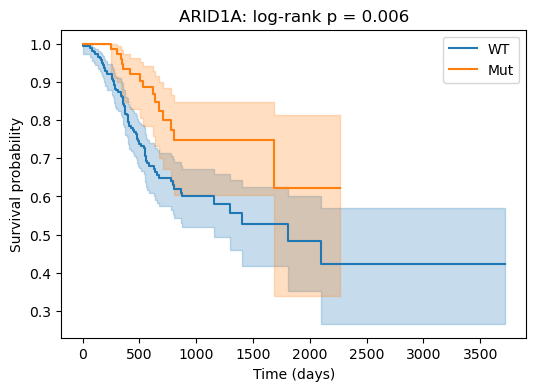

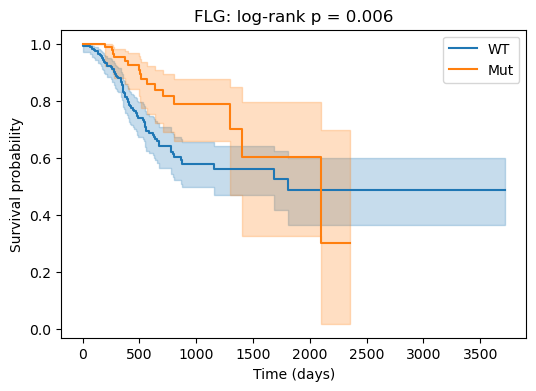

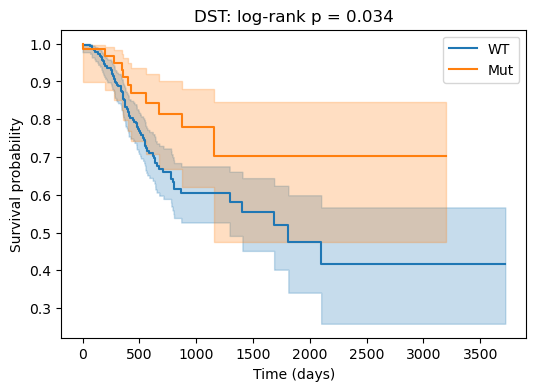

In [20]:
top3 = res_df.sort_values('logrank_p', ascending=True)['gene'].head(3).tolist()

kmf = KaplanMeierFitter()

for gene in top3:
    plt.figure(figsize=(6,4))
    for status, label in [(0, 'WT'), (1, 'Mut')]:
        sub = patient_meta[patient_meta[f'{gene}_mut'] == status]
        kmf.fit(sub['DSS.time'], event_observed=sub['DSS'], label=label)
        kmf.plot_survival_function(ci_show=True)
    pval = res_df.loc[res_df['gene'] == gene, 'logrank_p'].values[0]
    plt.title(f"{gene}: log-rank p = {pval:.3f}")
    plt.xlabel("Time (days)")
    plt.ylabel("Survival probability")
    plt.show()

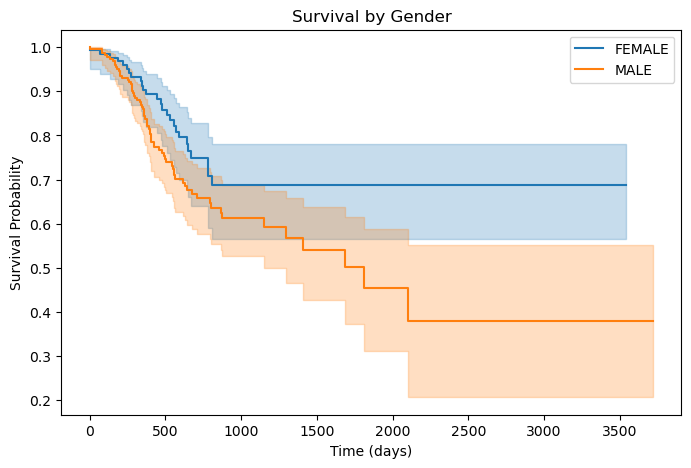

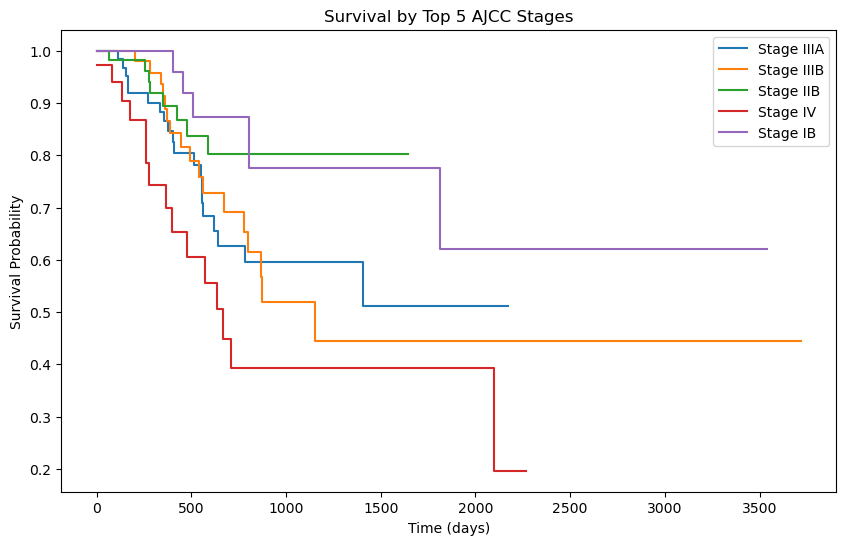

/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/lifelines/utils/__init__.py:1120: ConvergenceWarning: Column ajcc_pathologic_tumor_stage_Stage IA have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['DSS'].astype(bool)
>>> print(df.loc[events, 'ajcc_pathologic_tumor_stage_Stage IA'].var())
>>> print(df.loc[~events, 'ajcc_pathologic_tumor_stage_Stage IA'].var())

A very low variance means that the column ajcc_pathologic_tumor_stage_Stage IA completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence com

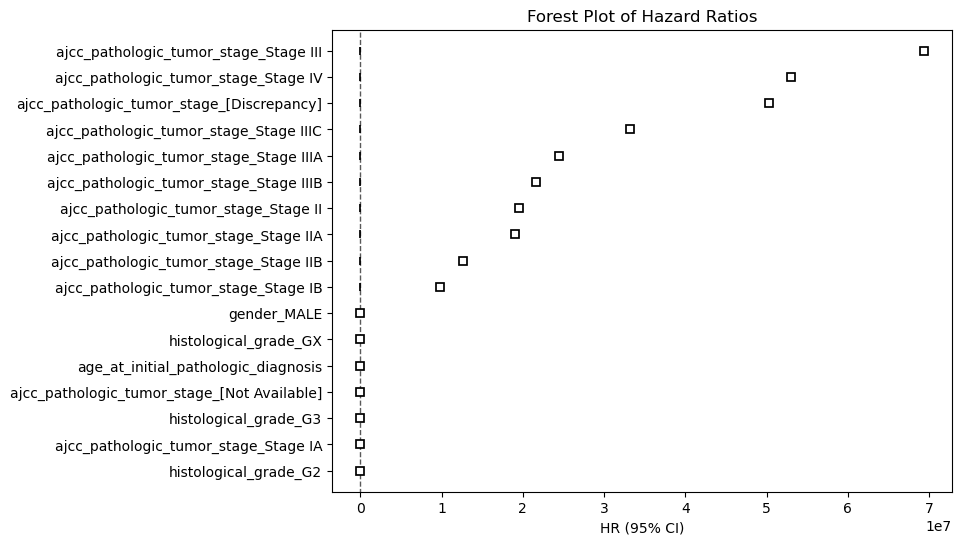

In [21]:
kmf = KaplanMeierFitter()
plt.figure(figsize=(8,5))
for grp, sub in patient_meta.groupby('gender'):
    kmf.fit(sub['DSS.time'], event_observed=sub['DSS'], label=grp)
    kmf.plot_survival_function(ci_show=True)
plt.title("Survival by Gender")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.show()

plt.figure(figsize=(10,6))
top_stages = patient_meta['ajcc_pathologic_tumor_stage'].value_counts().index[:5]
for stage in top_stages:
    sub = patient_meta[patient_meta['ajcc_pathologic_tumor_stage']==stage]
    kmf.fit(sub['DSS.time'], event_observed=sub['DSS'], label=stage)
    kmf.plot_survival_function(ci_show=False)
plt.title("Survival by Top 5 AJCC Stages")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.show()

numeric = ['age_at_initial_pathologic_diagnosis']
categorical = ['gender', 'ajcc_pathologic_tumor_stage', 'histological_grade']
df = patient_meta[['DSS.time','DSS'] + numeric + categorical].copy()
df['DSS.time'] = pd.to_numeric(df['DSS.time'], errors='coerce')
df['DSS']      = pd.to_numeric(df['DSS'], errors='coerce')
df = df.dropna(subset=['DSS.time','DSS'] + numeric)
df = pd.get_dummies(df, columns=categorical, drop_first=True)
cph = CoxPHFitter()
cph.fit(df, duration_col='DSS.time', event_col='DSS')

plt.figure(figsize=(8,6))
ax = cph.plot(hazard_ratios=True)
ax.set_title("Forest Plot of Hazard Ratios")
plt.show()